<a href="https://colab.research.google.com/github/Fatou-Kine3/github_task/blob/main/housing_price_forecasts.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

In [4]:
import pandas as pd

df = pd.read_csv("/content/train.csv")

df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
X = df[["GrLivArea", "YearBuilt"]]
y = df["SalePrice"]

In [6]:
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nData types:")
print(X.dtypes)
print(y.dtypes)

print("\nMissing values:")
print(X.isnull().sum())
print(y.isnull().sum())

X shape: (1460, 2)
y shape: (1460,)

Data types:
GrLivArea    int64
YearBuilt    int64
dtype: object
int64

Missing values:
GrLivArea    0
YearBuilt    0
dtype: int64
0


In [ ]:
### Problem 1 – Feature Selection

The selected features are `GrLivArea` and `YearBuilt`, and the target variable is `SalePrice`.

Both features are numerical variables. The shape, data types, and missing values were checked before modeling.

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

print("Training data:", X_train.shape)
print("Validation data:", X_val.shape)

Training data: (1095, 2)
Validation data: (365, 2)


In [8]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [9]:
y_pred = model.predict(X_val)

print(y_pred[:10])

[130445.81129484 306448.48211546  88741.8324304  168496.12883044
 227800.17562669  99569.77660678 186783.75135889 182056.44293199
  97457.76006969 151960.15487048]


In [10]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_val, y_pred)

print("Mean Squared Error (MSE):", mse)

Mean Squared Error (MSE): 2314465092.732015


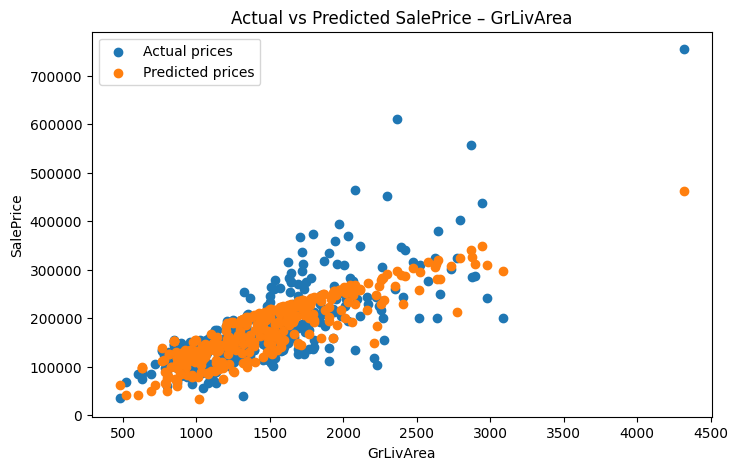

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(
    X_val["GrLivArea"],
    y_val,
    label="Actual prices"
)

plt.scatter(
    X_val["GrLivArea"],
    y_pred,
    label="Predicted prices"
)

plt.xlabel("GrLivArea")
plt.ylabel("SalePrice")
plt.title("Actual vs Predicted SalePrice – GrLivArea")
plt.legend()
plt.show()

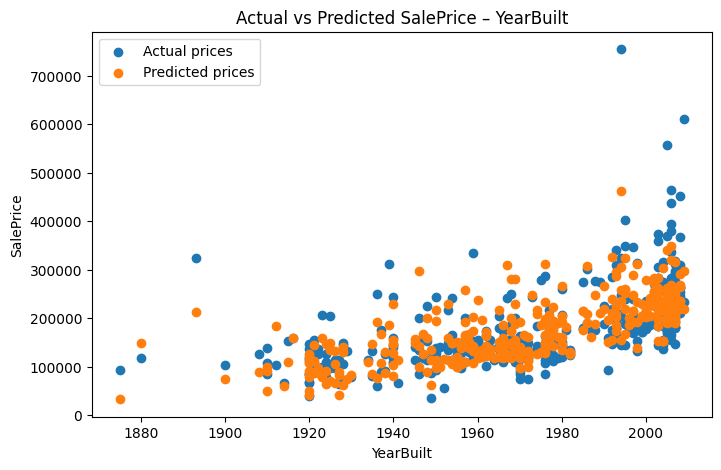

In [12]:
plt.figure(figsize=(8, 5))

plt.scatter(
    X_val["YearBuilt"],
    y_val,
    label="Actual prices"
)

plt.scatter(
    X_val["YearBuilt"],
    y_pred,
    label="Predicted prices"
)

plt.xlabel("YearBuilt")
plt.ylabel("SalePrice")
plt.title("Actual vs Predicted SalePrice – YearBuilt")
plt.legend()
plt.show()

In [ ]:
### Problem 2 – Linear Regression

The dataset was divided into 75% training data and 25% validation data.

A linear regression model was trained using only the training data. Predictions were then made on the validation data and evaluated using Mean Squared Error (MSE).

The scatter plots compare the actual house prices with the predicted prices using `GrLivArea` and `YearBuilt`.

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

In [14]:
models = {
    "Linear Regression": LinearRegression(),

    "SVR": make_pipeline(
        StandardScaler(),
        SVR()
    ),

    "Decision Tree": DecisionTreeRegressor(
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        random_state=42
    )
}

In [15]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)

    mse = mean_squared_error(y_val, y_pred)

    results[name] = mse

    print(name, "MSE:", mse)

Linear Regression MSE: 2314465092.732015
SVR MSE: 7169223057.829623
Decision Tree MSE: 2367486599.233866
Random Forest MSE: 1638291753.971873


In [16]:
results_df = pd.DataFrame(
    list(results.items()),
    columns=["Model", "MSE"]
)

results_df

,Model,MSE
0,Linear Regression,2.314465e+09
1,SVR,7.169223e+09
2,Decision Tree,2.367487e+09
3,Random Forest,1.638292e+09


In [17]:
best_model = results_df.loc[results_df["MSE"].idxmin()]

print("Best model:")
print(best_model)

Best model:
Model        Random Forest
MSE      1638291753.971873
Name: 3, dtype: object


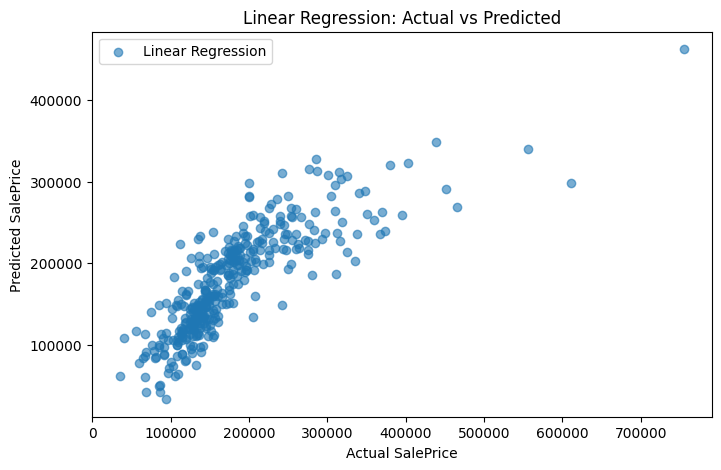

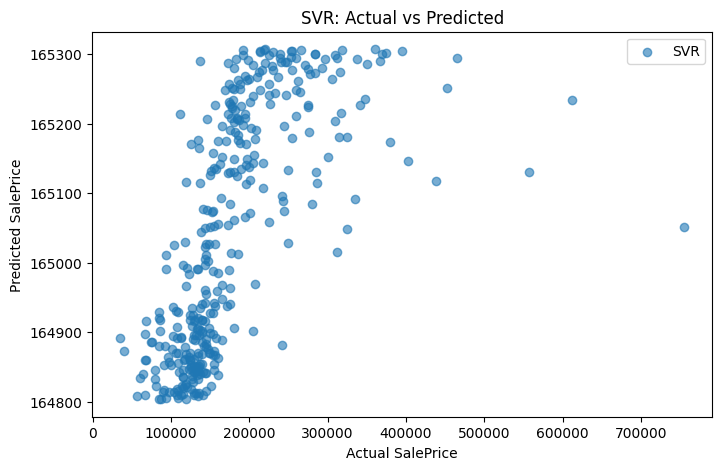

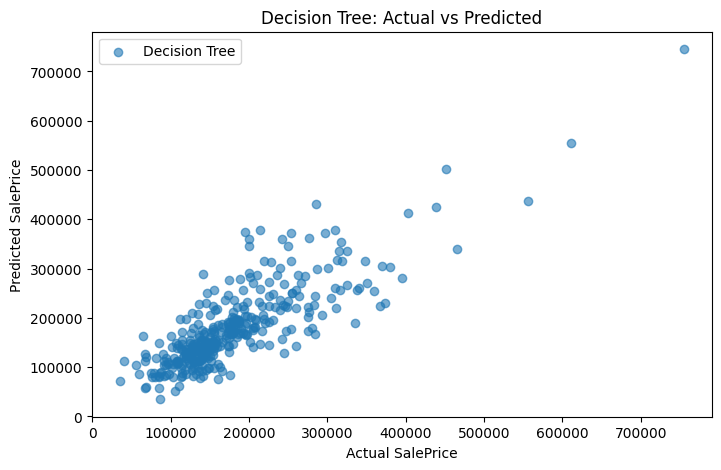

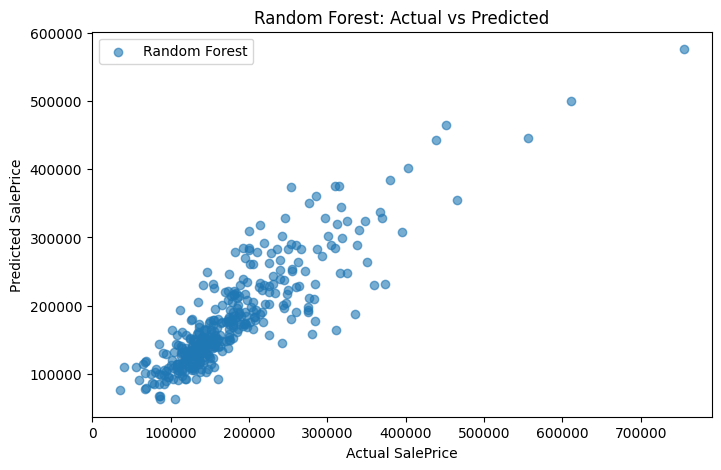

In [18]:
for name, model in models.items():

    y_pred = model.predict(X_val)

    plt.figure(figsize=(8, 5))

    plt.scatter(
        y_val,
        y_pred,
        alpha=0.6,
        label=name
    )

    plt.xlabel("Actual SalePrice")
    plt.ylabel("Predicted SalePrice")
    plt.title(f"{name}: Actual vs Predicted")
    plt.legend()

    plt.show()

In [ ]:
### Problem 3 – Comparison of Methods

The four regression methods were trained and evaluated using the same training and validation datasets.

The MSE values show that the model with the lowest MSE provides the smallest prediction error on the validation data.

The scatter plots show the relationship between the actual and predicted house prices. A model with predictions closer to the actual values provides better predictions.

In [19]:
features = [
    "GrLivArea",
    "YearBuilt",
    "OverallQual",
    "GarageCars",
    "TotalBsmtSF",
    "FullBath"
]

X_new = df[features]
y_new = df["SalePrice"]

In [ ]:
### Problem 4 – Feature Selection

I selected six numerical features: GrLivArea, YearBuilt, OverallQual,
GarageCars, TotalBsmtSF, and FullBath.

These variables were selected because they describe important characteristics
of a house, such as living area, construction year, overall quality,
garage capacity, basement area, and number of bathrooms.

In [20]:
X_new.isnull().sum()

,0
GrLivArea,0
YearBuilt,0
OverallQual,0
GarageCars,0
TotalBsmtSF,0
FullBath,0


In [21]:
X_new.isnull().sum()[X_new.isnull().sum() > 0]

,0


In [22]:
X_train_new, X_val_new, y_train_new, y_val_new = train_test_split(
    X_new,
    y_new,
    test_size=0.25,
    random_state=42
)

In [23]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

numeric_features = features

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features)
])

In [24]:
from sklearn.linear_model import LinearRegression

model_new = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

model_new.fit(X_train_new, y_train_new)

y_pred_new = model_new.predict(X_val_new)

In [25]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

model_new = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

model_new.fit(X_train_new, y_train_new)

y_pred_new = model_new.predict(X_val_new)

print("Linear Regression trained successfully.")

Linear Regression trained successfully.


In [26]:
from sklearn.metrics import mean_squared_error

mse_new = mean_squared_error(y_val_new, y_pred_new)

print("MSE with additional features:", mse_new)

MSE with additional features: 1432247517.3451717


In [27]:
print("MSE with 2 features:", results["Linear Regression"])
print("MSE with 6 features:", mse_new)

MSE with 2 features: 2314465092.732015
MSE with 6 features: 1432247517.3451717


In [ ]:
### Discussion

The model using additional features was compared with the model using only
GrLivArea and YearBuilt.

Adding relevant housing characteristics can provide the model with more
information about house prices. The MSE was compared to determine whether
the additional features improved the prediction performance.

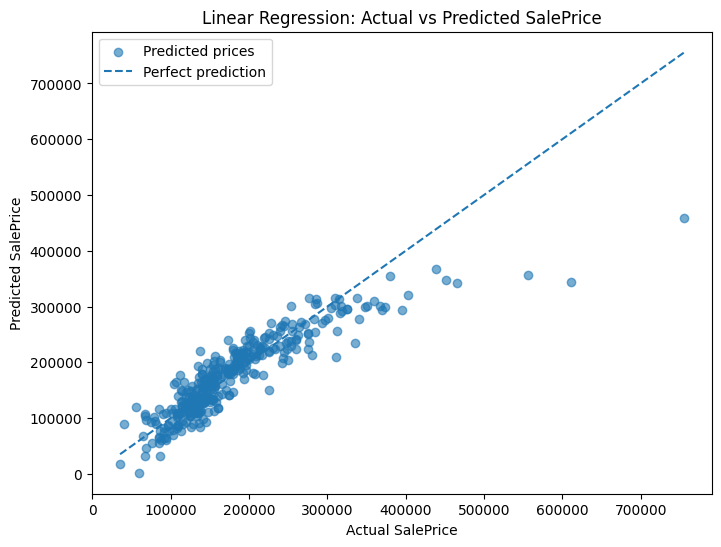

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    y_val_new,
    y_pred_new,
    alpha=0.6,
    label="Predicted prices"
)

# Ligne idéale : prédiction = valeur réelle
plt.plot(
    [y_val_new.min(), y_val_new.max()],
    [y_val_new.min(), y_val_new.max()],
    linestyle="--",
    label="Perfect prediction"
)

plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title("Linear Regression: Actual vs Predicted SalePrice")
plt.legend()
plt.show()

In [ ]:
### Visualization

The scatter plot compares the actual house prices with the prices predicted
by the linear regression model.

Points closer to the diagonal line indicate more accurate predictions.
The model does not predict all house prices perfectly, but the general
relationship between actual and predicted prices can be observed.